# 4-Site-FMO auf echter IBM-Hardware — 3 Qubits, ein durchgängiger Schaltkreis

**Korrektur vorweg.** Ich hatte gesagt, 4-Site-FMO ginge nicht auf Hardware und nur ein
2-Site-Modell sei machbar. Das war falsch — es galt für die *unkomprimierte* Variante
($n=720$, 11 Qubits, $2\cdot10^6$ CNOTs je Schritt). Mit Krylov-Kompression passt das
volle 4-Site-Modell in **3 Qubits**.

Der Grund: der Krylov-Raum $\mathcal{K}_m(\tilde P, \tilde x_0)$ enthält genau die ersten
$m$ Zeitschritte, und ein Hardware-Lauf ist durch die Kohärenzzeit ohnehin auf 5–8
Schritte begrenzt. Gemessen gegen qutip (Tiefe 2, ADO-skaliert, $\delta=0{,}02$):

| $m$ | Qubits | 2Q-Gatter/Schritt | Fehler $t=1$ | $t=3$ | $t=6$ |
|---|---|---|---|---|---|
| **4** | **3** | **31** | 1,1e-10 | 1,9e-10 | 2,0e-03 |
| 8 | 4 | 123 | 1,1e-10 | 1,9e-10 | 1,9e-09 |
| 128 | 8 | 31 400 | — | — | — |

Bei $m=4$ ist der *algorithmische* Fehler aufgrund der Krylov-compression 2·10⁻³ — weit unter dem, was die Hardware an
Rauschen beisteuert. Mehr Krylov-Dimensionen zu nehmen, wäre also verschenkt.

## Der Vergleich mit Seneviratne et al.

Dieselbe Qubit-Zahl wie in [ACS Omega **2024**, 9, 9666] — aber ein anderer Handel:

| | Seneviratne et al. | hier |
|---|---|---|
| Was läuft | Kraus-Operatoren $M_k$, $d\times d$ | HEOM-Propagator, Krylov-komprimiert |
| Qubits | 2 + 1 Ancilla | 2 + 1 Ancilla |
| 2Q-Gatter | 15 (SVD+Walsh) | 31 je Zeitschritt |
| Schaltkreis | **einer je Zeitpunkt** | **einer, durchgängig** |
| Klassischer Aufwand | TNPI-Abbildung **je Zeitpunkt** neu | einmalig, unabhängig von $n_{\rm steps}$ |

Sie rechnen die Dynamik klassisch voraus und nutzen den Quantenrechner als Auswerter.
Hier läuft der Zustand durch — genau der Unterschied, um den es in diesem Projekt geht.

**Ehrlich dazu:** Arnoldi baut den Krylov-Raum mit $m$ Matrix-Vektor-Produkten auf. Bei
$m=4$ und einem 6-Schritt-Lauf sind das 4 klassisch „angefasste" Schritte. Der
Unterschied wird erst über viele Schritte sichtbar: dasselbe $m$ trägt auch 100 oder
1000 Schritte, während die Kraus-Route jedes Mal neu rechnen muss.

In [6]:
import os, sys, time
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
import hardware as hw

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})
PIC = 'pictures'; os.makedirs(PIC, exist_ok=True)
# --- Parameter des Laufs -------------------------------------------------
N_SITES  = 4                       # 2, 3 oder 4 -- Block des FMO-Hamiltonians
LAM      = 35.0                    # Reorganisationsenergie [cm^-1], realistisches FMO
M_KRYLOV = 4                       # 4 -> 3 Qubits, 8 -> 4 Qubits
DELTA    = 10.0                    # Optimum des GESAMTfehlers -- siehe 1a
TIMES    = list(range(1, 11))      
METHOD   = 'svd'                   # 'svd' (empfohlen) oder 'sznagy'
DEFER    = True                    # aufgeschobene Messung -- siehe 1c
FLOOR    = False                   # Nullkanal je Zeit: misst den Rauschboden direkt
PAIRS    = [(0, 1)]                # Kohaerenzen; je Paar +2 Schaltkreise/Zeit
SHOTS    = 2048
BACKEND  = 'ibm_kingston'          # von den zugaenglichen QPUs die beste
DT_FS = 40.0

MODEL, RHO0 = hw.make_model(N_SITES, lam=LAM)
grid = hw.build_hardware_grid(n_sites=N_SITES, m=M_KRYLOV, dt_fs=DT_FS, delta=DELTA,
                              model=MODEL, rho0=RHO0)
N    = grid['d']
cols = plt.cm.tab10(np.arange(N))

  4 Sites, Tiefe 2, Nk = 1
  Gitter: m = 4 -> gepolstert 4, 3 Qubits, U ist 8x8
  s = 0.99183592   ||H_m|| = 0.991836
  Singulaerwerte von H_m/s: 0.112950 bis 1.000000
  Aufbau 12.9 s (einmalig, unabhaengig von der Zahl der Zeitschritte)


## 1a  Die Parameterwahl: $\lambda$, $\delta$, $\Delta t$ und $t_{\max}$

Vier Parameter hängen zusammen, und der einzige sinnvolle Maßstab ist der **Gesamtfehler**

$$\varepsilon_{\rm ges} = \sqrt{\varepsilon_{\rm Algorithmus}^2 + \varepsilon_{\rm Statistik}^2}$$

Der Algorithmusfehler kommt aus der Krylov-Abschneidung bei $m=4$, der statistische aus
$\delta\rho = \lVert r\rVert\lambda_t/(2\sqrt{N})$. Alles unten gemessen, $t=6$, 4096 Shots.

### $\delta = 10$, nicht 2

| $\delta$ | Shots für ±0,03 | Algorithmus | Statistik | **Gesamt** | CZ |
|---|---|---|---|---|---|
| 0,02 | 23 633 | 1,97e-3 | 0,0716 | 0,0716 | 63 |
| 0,5 | 1 040 | 1,97e-3 | 0,0151 | 0,0152 | 63 |
| 2 | 439 | 1,98e-3 | 0,0098 | 0,0100 | 63 |
| **10** | **292** | **2,68e-3** | **0,0080** | **0,0084** | 63 |
| 30 | 279 | 4,70e-3 | 0,0080 | 0,0093 | 63 |

**Die Gatterzahl ist von $\delta$ unabhängig** — 63 CZ bei jedem Wert. $\delta$ kostet also
nichts in der Tiefe, nur in Shots und Genauigkeit.

Frühere Fassungen dieses Notebooks empfahlen $\delta=2$. Das war zu vorsichtig: der
Algorithmusfehler von 2,7e-3 bei $\delta=10$ liegt weit unter der statistischen Schwelle
von ~0,010 und fällt gar nicht ins Gewicht, während die 33 % weniger Shots direkt
durchschlagen. Ab $\delta\approx10$ sättigt der Shot-Gewinn (292 → 279), der
Algorithmusfehler wächst aber weiter — deshalb 10 und nicht mehr.

### $\lambda = 35$ verkürzt den nutzbaren Zeitbereich

Bei stärkerer Kopplung läuft die Dynamik schneller, und der Krylov-Raum $m=4$ trägt
weniger weit. Algorithmusfehler gegen $t$, bei $\delta=10$:

| $\lambda$ | $t=1$ | $t=3$ | $t=4$ | $t=5$ | $t=6$ | $t=8$ | $t=10$ |
|---|---|---|---|---|---|---|---|
| 3 | 1,1e-10 | 1,9e-10 | 4,1e-4 | 1,4e-3 | 2,7e-3 | 4,9e-3 | 9,4e-3 |
| **35** | 5,8e-12 | 2,1e-10 | 2,2e-3 | **9,0e-3** | 2,2e-2 | 5,9e-2 | 7,6e-2 |

Die statistische Schwelle liegt bei 4096 Shots bei ~0,010. Bei $\lambda=3$ bleibt der
Algorithmusfehler bis $t=10$ darunter, bei $\lambda=35$ nur bis $t=5$. Deshalb steht
`TIMES = range(1, 6)`.

Warum nicht einfach $m=8$? Weil es die Hardware ruiniert: 476 statt 63 CZ, Treue 0,23 statt
0,83. Der Algorithmusfehler würde auf 1e-8 fallen, aber das Ergebnis wäre zu 77 % Rauschen.
Bei $m=4$ und $t\le5$ ist der Gesamtfehler 0,013 — und die Treue bleibt bei 0,86.

### $\Delta t = 20$ fs geht **nicht** ohne Weiteres

Naheliegend wäre, dieselbe physikalische Zeit mit halb so vielen Schritten abzudecken. Der
Krylov-Raum trägt aber eine feste Zahl von *Schritten*, nicht eine feste *Zeit* — bei
doppeltem $\Delta t$ ändert sich der Zustand je Schritt stärker, und $m=4$ reicht nicht mehr:

| $\lambda$ | $\Delta t$ | Algorithmus $t=6$ | Statistik | Gesamt |
|---|---|---|---|---|
| 3 | 10 fs | 2,7e-3 | 0,0080 | **0,0084** |
| 3 | 20 fs | 1,3e-2 | 0,0080 | 0,0154 |
| 35 | 10 fs | 2,2e-2 | 0,0097 | **0,0238** |
| 35 | 20 fs | 3,7e-2 | 0,0096 | 0,0379 |

Der Gesamtfehler verdoppelt sich, die Gatterzahl bleibt gleich. $\Delta t = 20$ fs wäre nur
mit größerem $m$ sinnvoll — und das kostet dann Gatter.

### Die Systemgröße ist ein Parameter

`N_SITES` lässt sich auf 2, 3 oder 4 setzen — genommen wird der führende Block des
FMO-Hamiltonians. Der Punkt dabei ist, dass es auf der Maschine **nichts kostet**:

| `N_SITES` | ADOs | $n$ | Qubits | 2Q-Gatter | Treue $t=1$ / $t=6$ | Schaltkreise | QPU-Zeit |
|---|---|---|---|---|---|---|---|
| 2 | 15 | 60 | **3** | 30…167 | 0,923 / 0,641 | 24 | 26,0 s |
| 3 | 28 | 252 | **3** | 30…167 | 0,923 / 0,641 | 30 | 32,5 s |
| 4 | 45 | 720 | **3** | 30…167 | 0,923 / 0,641 | 36 | 39,0 s |

Qubit-Zahl, Gatterzahl und Treue sind **identisch** — der Schaltkreis ist immer dasselbe
$8\times8$-Gatter auf 3 Qubits. Nur die Zahl der *Ablese*schaltkreise wächst mit $N$
(eine je Population), und damit die QPU-Zeit.

Der Grund: die nötige Krylov-Dimension hängt von der Zahl der **Zeitschritte** ab, nicht
von der Systemgröße. Gemessen bei $m=4$ über 6 Schritte: Fehler 2,7e-3 ($N=2$),
3,5e-3 ($N=3$), 2,0e-3 ($N=4$).

**Nimm also $N=4$.** Ein kleineres System zu rechnen bringt auf der Hardware keinen
Vorteil — es spart nur ein paar Ablesekreise und liefert weniger Physik. $N=2$ ist
nützlich, wenn du gegen das unkomprimierte Notebook in
`../without_compression/2_site_FMO/` vergleichen willst.

## 1c  Aufgeschobene Messung — warum der erste Hardware-Lauf scheiterte

Der erste Lauf auf `ibm_kingston` (t=1…10, 2048 Shots) lieferte eine fast flache
Kurve. Drei Befunde zeigen, dass das **nicht** normales Gatterrauschen war:

**Das gemessene $q$ hing kaum von $t$ ab.** Der Kanal $(++,0,1)$ lieferte

| $t$ | 1 | 2 | 3 | 10 |
|---|---|---|---|---|
| $q$ ideal | 0,449 | 0,659 | 0,772 | 0,666 |
| $q$ gemessen | 0,443 | 0,433 | 0,417 | 0,434 |

Der Schaltkreisinhalt schlug also kaum durch — bei 13 bzw. 103 Gattern dasselbe Ergebnis.

**Kein einheitliches Depolarisationsmodell passt.** Löst man
$q = (1-p)\,q_{\rm ideal} + p/4$ nach $p$ auf, kommen für die sechs Kanäle bei $t=1$
heraus: 0,51 / 0,70 / 0,27 / 0,29 / 0,03 / 0,63. Bei gleichmäßigem Rauschen müsste
überall dasselbe $p$ stehen.

**Die publizierten Fehlerraten erklären es nicht.** RMS-Abweichung eines Aer-Laufs
mit Rauschmodell von den echten Daten:

| Modell | RMS |
|---|---|
| rauschfrei | 0,148 |
| kingstons Werte (2Q = 3,05e-3) | 0,134 |
| 2Q = 0,05 (**16-fach**) | **0,056** |

Man braucht einen effektiven Zweiqubit-Fehler von 5 %, um die Daten zu treffen. Der
Fehler steckt also nicht in den Gattern, sondern zwischen ihnen: **jede
Mid-Circuit-Messung dephasiert die benachbarten Systemqubits**, und der Reset ist auf
IBM-Hardware selbst wieder eine Messung mit bedingtem X. Die Ancilla q23 lag direkt
neben dem Systemqubit q16, und der Schaltkreis tat das zehnmal. Das erklärt auch, warum
schon $t=1$ mit einer einzigen Messung sichtbar daneben lag.

### Die Abhilfe

Statt eine Ancilla zu messen und zurückzusetzen, bekommt **jeder Zeitschritt ein eigenes
frisches Ancilla-Qubit**, und alle Messungen stehen am Ende. Nach dem Prinzip der
aufgeschobenen Messung ist das exakt äquivalent, solange kein Gatter von einem
Messergebnis abhängt — und das tut hier keines.

| $t$ | mit Reset | aufgeschoben |
|---|---|---|
| 1 | 10 CZ, 1 Reset | 10 CZ, **0 Reset** |
| 5 | 42 CZ, 5 Reset | 42 CZ, **0 Reset** |
| 10 | 82 CZ, 10 Reset | 82 CZ, **0 Reset** |

**Null zusätzliche Zweiqubit-Gatter**, ~5 % mehr Tiefe, dafür $t$ statt 1 Ancilla
(12 Qubits bei $t=10$ — kingston hat 156). In Aer geben beide Varianten dasselbe
(0,0595 gegen 0,0568, der Rest ist Shot-Rauschen).

Schaltbar über `DEFER`. `DEFER = False` reproduziert den alten Lauf.

### 1b  SVD statt Sz.-Nagy — Faktor 2,6 an Gattern

Die volle Sz.-Nagy-Dilatation macht aus $M$ ein **beliebiges** 3-Qubit-Unitary, und das
kostet $\tfrac{23}{48}4^3\approx20$ CNOTs. Seneviratne et al. zerlegen stattdessen

$$M = U\Sigma V^\dagger,\qquad U_\Sigma = \begin{pmatrix}\Sigma_+ & 0\\ 0 & \Sigma_-\end{pmatrix},\qquad \Sigma_\pm = \sigma_j \pm i\sqrt{1-\sigma_j^2}$$

und dilatieren **nur die Diagonale**. $U$ und $V^\dagger$ wirken auf die 2 Systemqubits —
ein beliebiges 2-Qubit-Unitary braucht 3 CNOTs — und eine Diagonale auf 3 Qubits kostet
$\sim2^3$ statt $4^3$. $\sigma_j\le1$ ist garantiert, weil $s\ge\lVert H_m\rVert$.

Gemessen auf linearer Kette, Zweiqubit-Gatter je Schaltkreis und Treue bei 2,64e-3:

| $t$ | Sz.-Nagy | Treue | **SVD** | **Treue** |
|---|---|---|---|---|
| 1 | 30 | 0,92 | **13** | **0,97** |
| 3 | 84 | 0,80 | **33** | **0,92** |
| 6 | 166 | 0,64 | **63** | **0,85** |
| 10 | 272 | 0,49 | **103** | **0,76** |

**Die Durchgängigkeit ändert sich dadurch nicht.** Beides sind Dilatationen desselben
$M$ — der $|0\rangle$-Ancillazweig trägt in beiden Fällen $M$, sie unterscheiden sich nur
im verworfenen $|1\rangle$-Zweig. Das Systemregister wird weiterhin nie gemessen und nie
neu präpariert, und klassisch wird die SVD **einmal** berechnet, so wie vorher die
Dilatation einmal berechnet wurde.

Deshalb geht `TIMES` jetzt bis 10 statt bis 6: 103 CZ, Treue 0,76, algorithmischer
Fehler bei $m=4$ noch $7\cdot10^{-3}$. Über $t\approx12$ hinaus lohnt es nicht mehr — dort
wächst der $m=4$-Fehler schneller, als die Treue fällt, und $m$ zu erhöhen kostet mehr
(bei $m=8$ sind es 4 Qubits und 75 CZ **je Schritt**), als es bringt.

## 1  Die Schaltkreise

Je Auslesezeit **und je Ablesezeile** ein Schaltkreis — die Messung zerstört den
Zustand, also lässt sich nicht alles aus einem Lauf holen. Im komprimierten Krylov-Raum
sind die Ablesezeilen $r_{jj}$ **dicht** (anders als ohne Kompression, wo sie
Basisvektoren sind), deshalb braucht jede ihre eigene Basisdrehung $B^\dagger$ mit
$B|0\rangle = \chi_j$, $\chi_j = \overline{r_j}/\lVert r_j\rVert$. Gemessen wird dann

$$q_j = P\big(|0\dots0\rangle \,\big|\, \text{Ancilla-Protokoll} = 0\dots0\big),
\qquad \rho_{jj} = \lVert r_j\rVert\,\lambda_t\sqrt{q_j},
\qquad \lambda_t = \lVert y_0\rVert\,s^t\sqrt{p_t}.$$

Kohärenzen über die ++/RR-Drehung wie gehabt, $\rho_{++} = \tfrac12(\rho_{aa}+\rho_{bb})+\mathrm{Re}\,\rho_{ab}$.

Nur legale Befehle: `unitary`, `measure`, `reset`. Kein `save_statevector` — das gibt es
auf Hardware nicht.

| Ohne Deferred Measurement (`defer=False`) | Mit Deferred Measurement (`defer=True`) |
| :--- | :--- |
| **1.** Zeitschritt 1 koppelt an Ancilla 0. | **1.** Zeitschritt 1 koppelt an Ancilla 0 (Start \|0⟩). Ancilla 0 wird danach nie wieder berührt. |
| **2.** Ancilla 0 wird gemessen und auf \|0⟩ zurückgesetzt. | **2.** Zeitschritt 2 koppelt an Ancilla 1 (Start \|0⟩). |
| **3.** Zeitschritt 2 koppelt an diese nun wieder in \|0⟩ präparierte Ancilla 0. | **3.** Zeitschritt 3 koppelt an Ancilla 2 (Start \|0⟩). |
| **4.** Post-Selection akzeptiert nur Shots, bei denen die Zwischenmessung den Wert `0` ergab. | **4.** Am Ende des gesamten Schaltkreises werden Ancilla 0, 1 und 2 gemessen. Die Post-Selection verlangt exakt denselben Bitstring `000`. |

Es ist zu beachten dass die "Diagonal" Matrix nicht über alle qubits geht sondern immer nur über 3. Man kann das an den Zahlen am linken rand der anzeige "Diagonal" sehen. Jedes H ganz am Anfang gehört zu dem H der SVD das am anderen Ende von "Diagonal" steht. Es wird nur graphisch vorgezogen weil nichts davor steht.

  84 Schaltkreise = 14 Zeiten x (4 Populationen + 2 x 1 Paare)


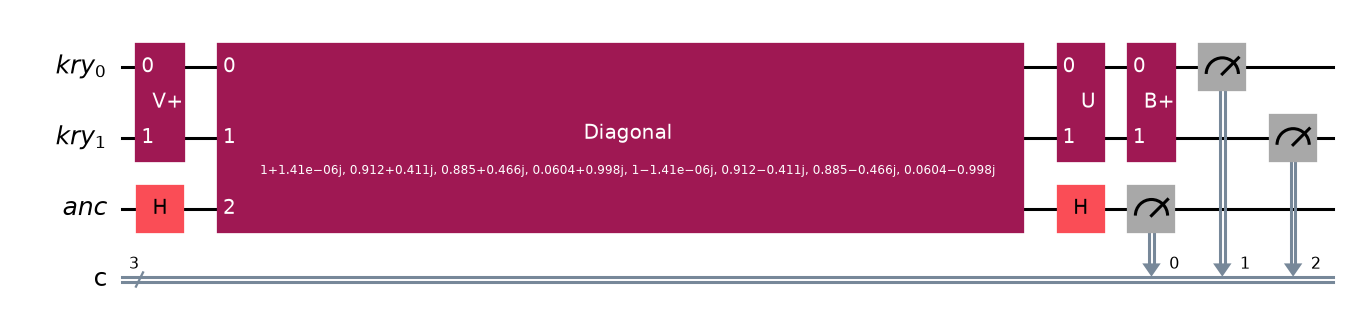

In [7]:
jobs = hw.hardware_circuits(grid, TIMES, PAIRS, method=METHOD, defer=DEFER,
                            floor=FLOOR)
print(f"  {len(jobs)} Schaltkreise = {len(TIMES)} Zeiten x "
      f"({N} Populationen + 2 x {len(PAIRS)} Paare)")
jobs[6*1-1]['circuit'].draw('mpl', fold=17)     # Schaltkreis zur Zeit t=3 -> 3 Blöcke

## 2  Was der Lauf kostet — **vor** dem Absenden

Bei 10 Minuten QPU-Zeit pro Monat lohnt es sich, das vorher zu wissen. Zwei Dinge
gehen in die Schätzung ein, und beide sind Annahmen, keine Zusagen:

* **Topologie.** IBMs Heavy-Hex-Gitter hat **keine Dreiecke** — drei paarweise
  verbundene Qubits gibt es dort nicht. Die fehlenden Verbindungen kosten SWAPs:
  gemessen 99 Zweiqubit-Gatter bei $t=6$ mit all-to-all, **167** auf einer linearen
  Kette. Die Zelle rechnet mit der linearen Kette.
* **`rep_delay`.** Die Wartezeit zwischen den Shots, damit die Qubits relaxieren.
  Sie macht **~94 %** der QPU-Zeit aus. 250 µs ist konservativ; mit aktivem Reset
  geht es schneller.

In [8]:
kosten = hw.report_cost(grid, jobs, shots=SHOTS)

budget = 10 * 60          # 10 Minuten pro Monat
print(f"""
  Dein Budget: {budget} s pro Monat -> etwa {int(budget/kosten['qpu_seconds'])} Laeufe
  dieser Groesse.

  Stellschrauben, falls es knapp wird:
    Shots halbieren      -> halbe Zeit, Fehlerbalken x 1.41
    ein Zeitpunkt weniger-> {kosten['qpu_seconds']/len(TIMES):.0f} s gespart
    Kohaerenzen weglassen-> {2*len(PAIRS)/(N+2*len(PAIRS))*100:.0f} % gespart""")

  84 Schaltkreise, 3 System- + bis 13 Ancilla-Qubits = 16, 1024 Shots je Schaltkreis, Dilatation 'svd'
  Messung: aufgeschoben -- 0 Resets, alles am Ende
  Zweiqubit-Gatter: 13 bis 281 (Median 115), Tiefe bis 593

    t  2Q-Gatter  Tiefe  Treue (Gatter)
    1         13     59           0.965
    2         24    101           0.937
    3         38    143           0.903
    4         52    185           0.870
    5         69    227           0.831
    6         85    266           0.796
    7        105    308           0.755
    8        124    347           0.718
    9        147    389           0.675
   10        169    428           0.637
   11        195    470           0.594
   12        220    509           0.556
   13        248    548           0.516
   14        280    590           0.474

  geschaetzte QPU-Zeit : 27.7 s  (0.46 min)
    davon rep_delay    : 26.8 s (97%)
  Annahmen: 2.66e-03 Fehler je 2Q-Gatter, 68 ns je 2Q, 311 us rep_delay, Topologie: lineare Kette
  (re

## 3  Kostenlos gegenprüfen

Dieselben Schaltkreise in Aer, bevor QPU-Zeit verbraucht wird. Das findet
Konstruktionsfehler, kostet nichts und liefert die Referenz, gegen die sich das
Hardware-Ergebnis später einordnen lässt: **was hier schon danebenliegt, wird auf der
Maschine nicht besser.**

In [9]:
rho_aer, err_aer, info_aer = hw.verify_in_aer(grid, jobs, shots=SHOTS, pairs=PAIRS)

14.3%. Run time:   0.00s. Est. time left: 00:00:00:00
21.4%. Run time:   0.01s. Est. time left: 00:00:00:00
35.7%. Run time:   0.01s. Est. time left: 00:00:00:00
42.9%. Run time:   0.01s. Est. time left: 00:00:00:00
50.0%. Run time:   0.01s. Est. time left: 00:00:00:00
64.3%. Run time:   0.01s. Est. time left: 00:00:00:00
71.4%. Run time:   0.01s. Est. time left: 00:00:00:00
85.7%. Run time:   0.02s. Est. time left: 00:00:00:00
92.9%. Run time:   0.02s. Est. time left: 00:00:00:00
100.0%. Run time:   0.02s. Est. time left: 00:00:00:00
Total run time:   0.02s

  Aer gegen qutip HEOMSolver:
    t =   20 fs | p_succ 0.981 | Spur 1.0050 | max|dPop| ueber p_t 0.0091 | spurnormiert 0.0085
    t =   40 fs | p_succ 0.972 | Spur 0.9789 | max|dPop| ueber p_t 0.0243 | spurnormiert 0.0100
    t =   60 fs | p_succ 0.936 | Spur 0.9756 | max|dPop| ueber p_t 0.0226 | spurnormiert 0.0102
    t =   80 fs | p_succ 0.919 | Spur 0.9746 | max|dPop| ueber p_t 0.0351 | spurnormiert 0.0258
    t =  100 fs | p_

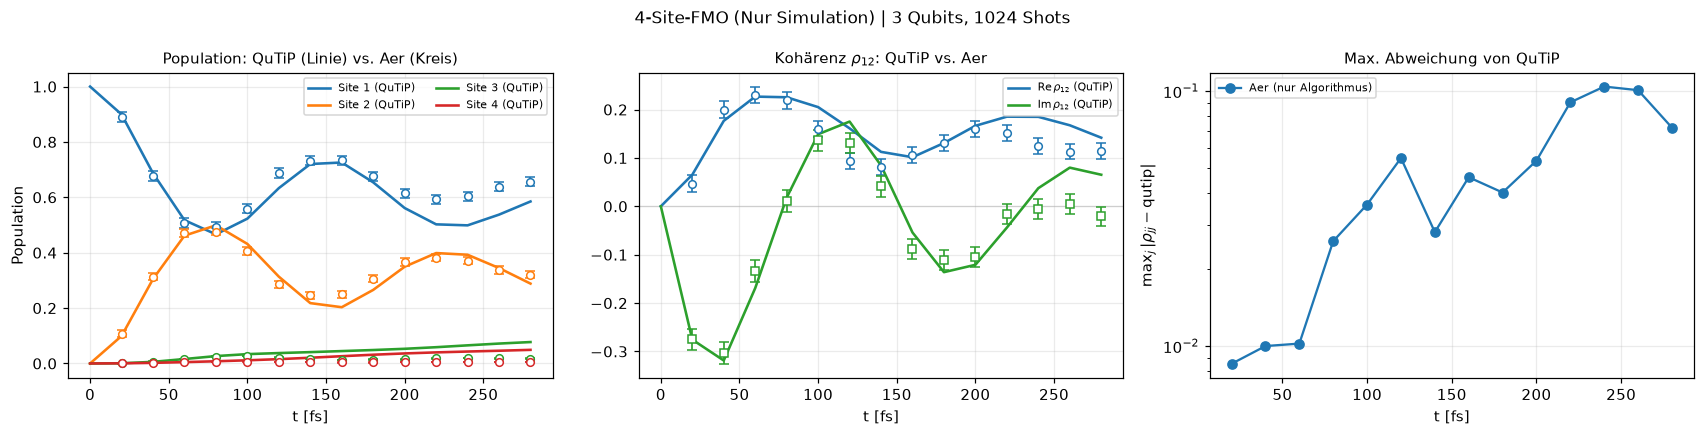

In [10]:
# Basisdaten aus Aer extrahieren
ts     = info_aer['t_index']
ref    = info_aer['reference']
aer_tr = info_aer['rho_tr']

# Zeitachsen berechnen
t_ex = np.arange(max(TIMES) + 1) * grid['dt_fs']
t_pt = ts * grid['dt_fs']
ok_a = np.isfinite(np.real(rho_aer[:, 0, 0]))

# 3 Panels fest vorgeben
fig, ax = plt.subplots(1, 3, figsize=(15.6, 4))

# --- Panel (a): Populationen ---
for j in range(N):
    # QuTiP (Linie)
    ax[0].plot(t_ex, np.real(ref[:, j, j]), color=cols[j], lw=1.7,
               label=f'Site {j+1} (QuTiP)')
    # Qiskit Aer (weiße Kreise)
    ax[0].errorbar(t_pt[ok_a], np.real(aer_tr[ok_a, j, j]),
                   yerr=err_aer[ok_a, j, j], fmt='o', ms=5, capsize=3,
                   color=cols[j], mfc='white', lw=1.1)

ax[0].set_ylabel('Population')
ax[0].set_title('Population: QuTiP (Linie) vs. Aer (Kreis)')
# Legende begrenzen, damit sie nicht doppelt so lang wird (Linien reichen für Zuordnung)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles[:N], labels[:N], ncol=2, fontsize=7)


# --- Panel (b): Kohärenzen ---
a, b = PAIRS[0]
for part, lab, mk, cc, ee in ((np.real, r'\mathrm{Re}', 'o', 'C0', err_aer),
                              (np.imag, r'\mathrm{Im}', 's', 'C2',
                               info_aer['rho_err_im'])):
    # QuTiP (Linie)
    ax[1].plot(t_ex, part(ref[:, a, b]), lw=1.7, color=cc,
               label=rf'${lab}\,\rho_{{{a+1}{b+1}}}$ (QuTiP)')
    # Qiskit Aer (Marker)
    ax[1].errorbar(t_pt[ok_a], part(aer_tr[ok_a, a, b]), yerr=ee[ok_a, a, b],
                   fmt=mk, ms=5, capsize=3, mfc='white', lw=1.1, color=cc)

ax[1].axhline(0, color='0.85', lw=.8, zorder=0)
ax[1].set_title(rf'Kohärenz $\rho_{{{a+1}{b+1}}}$: QuTiP vs. Aer')
ax[1].legend(fontsize=7)


# --- Panel (c): Abweichung ---
dmax = lambda R, k: np.abs(np.real(np.diag(R[k])) - np.real(np.diag(ref[ts[k]]))).max()

# Zeichne nur Aer-Abweichung
ax[2].semilogy(t_pt[ok_a], [dmax(aer_tr, k) for k in np.where(ok_a)[0]],
               'o-', color='C0', label='Aer (nur Algorithmus)')

ax[2].set_ylabel(r'max$_j\,|\rho_{jj} - $qutip$|$')
ax[2].set_title('Max. Abweichung von QuTiP')
ax[2].legend(fontsize=7)


# --- Formatierung ---
for A in ax:
    A.set_xlabel('t [fs]')
    A.grid(alpha=.25)

fig.suptitle(f'4-Site-FMO (Nur Simulation) | {grid["n_qubits"]} Qubits, {SHOTS} Shots', 
             fontsize=11, color='black')
fig.tight_layout()

# Zeigt den Plot direkt an (vorausgesetzt %matplotlib inline ist in Jupyter aktiv)
plt.show()

## 4  Auf die echte Maschine

### Einmalig einrichten

```bash
pip install qiskit-ibm-runtime
```

```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(token="DEIN_TOKEN", overwrite=True)
```

Den Token bekommst du sofort nach der Registrierung auf der IBM Quantum Platform —
da gibt es **keine Wartezeit**. Den genauen `channel`-Namen und die aktuellen Limits
des kostenlosen Plans nimm bitte von der Plattform selbst; die haben sich mehrfach
geändert, und ich will dir da nichts Falsches sagen.

### Was beim Absenden passiert

Du lädst **keine Datei** hoch. `run_on_backend` transpiliert lokal gegen die echte ISA
der Maschine (Kopplungsgraph, Basisgatter, Kalibrierung) und schickt nur die
serialisierten Schaltkreise. Zurück kommen Zählraten.

Deshalb musst du **je Backend neu transpilieren** — das ist der eine Parameter
`backend=`, der Rest des Codes bleibt gleich.

### Warum `ibm_kingston`

Zugänglich sind nur `kingston`, `fez` und `marrakesh` (die übrigen tragen ein Schloss).
Für 63 CZ bei $t=6$ und zwei Auslesequbits:

| QPU | Typ | 2Q layered | Auslesen | Gattertreue | Queue |
|---|---|---|---|---|---|
| **ibm_kingston** | Heron r2 | **3,05e-3** | 1,001e-2 | **0,809** | 41 |
| ibm_fez | Heron r2 | 4,75e-3 | 9,888e-3 | 0,727 | **568** |
| ibm_marrakesh | Heron r2 | 5,16e-3 | 1,318e-2 | 0,703 | 20 |

`kingston` hat die besten Gatter und praktisch dasselbe Auslesen wie `fez`, dessen Queue
mit 568 Jobs unbrauchbar ist. `marrakesh` hat mit 20 die kürzeste Schlange, aber 70 % mehr
Gatterfehler — das kostet mehr, als die Wartezeit wert ist.

### Fehlerunterdrückung

`run_on_backend` schaltet zwei Dinge zu, beide kostenlos in QPU-Zeit:

* **Pauli-Twirling** (Gatter und Messung) wandelt **kohärente** Fehler in stochastische um.
  Genau der richtige Hebel hier: der Schaltkreis wiederholt *dasselbe* Gatter $n$-mal, ein
  systematischer Rotationsfehler addiert sich also kohärent auf — Fehler $\propto n$ statt
  $\propto\sqrt n$.
* **Dynamical Decoupling (XY4)** unterdrückt Dephasierung im Leerlauf. Besonders wirksam,
  weil das Systemregister während **jeder** Ancilla-Messung und jedes Resets untätig
  herumliegt: bei ~2 µs je Schritt und 5 Schritten sind das ~10 µs gegen $T_2\approx200$ µs.

Abschalten mit `run_on_backend(..., twirling=False, dd=False)`.

### Den ausgeführten Schaltkreis ansehen

Der ISA-Schaltkreis wird **lokal** erzeugt und von der Runtime nicht noch einmal zerlegt.
`isa_report(jobs)` listet ihn auf, und er steht in `jobs[i]['transpiled']`:

```python
jobs[3]['transpiled'].draw('mpl', fold=-1)          # ansehen
from qiskit import qpy
qpy.dump([j['transpiled'] for j in jobs], open('isa.qpy','wb'))   # sichern
```

Twirling und DD fügen zur Laufzeit nur Pauli-Gatter bzw. Pulse ein und ändern die Struktur
nicht. Nach dem Lauf liefert auch `job.inputs['pubs']` zurück, was abgeschickt wurde.

In [34]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Der Token liegt bereits in ~/.qiskit/qiskit-ibm.json (dort beim ersten Lauf
# hinterlegt, Datei jetzt auf chmod 600).  Er muss NICHT mehr hier stehen --
# so kann er auch nicht versehentlich mit dem Notebook auf GitHub landen.
# Nur fuer ein NEUES Konto: TOKEN einmalig fuellen, ausfuehren, wieder leeren.
TOKEN = ""
if TOKEN:
    QiskitRuntimeService.save_account(token=TOKEN, overwrite=True)
    print("  neues Konto hinterlegt")
else:
    try:
        QiskitRuntimeService()          # nutzt das gespeicherte Konto
        print("  gespeichertes Konto gefunden -- kein Token noetig")
    except Exception as e:
        print(f"  KEIN Konto: {e}\n  -> TOKEN oben einmalig eintragen.")

# Welcher Lauf soll ausgewertet werden?  Die Datei muss zu TIMES und FLOOR
# passen, sonst greift die Pruefung weiter unten:
#   ibm_kingston_kry_200fs_mit_reset.npy    60 Kreise, t=1..10, MIT Reset
#   ibm_kingston_kry_200fs_ohne_reset.npy   70 Kreise, t=1..10, aufgeschoben
#   ibm_kingston_kry_500fs_ohne_reset.npy  175 Kreise, t=1..25, aufgeschoben
COUNTS_FILE = 'ibm_kingston_kry_500fs_ohne_reset.npy'

# ACHTUNG: verbraucht QPU-Zeit.  Erst ausfuehren, wenn Abschnitt 2 und 3 passen.
LOSSCHICKEN = False          # auf True setzen, wenn du bereit bist

if LOSSCHICKEN:
    # alten Lauf nicht verlieren -- er ist der Vergleichspunkt fuer die
    # Diagnose aus 1c (mit Reset) gegen den neuen (aufgeschobene Messung)
    if os.path.exists(COUNTS_FILE):
        sich = COUNTS_FILE.replace('.npy',
                                   f"_{time.strftime('%Y%m%d_%H%M%S')}.npy")
        os.rename(COUNTS_FILE, sich)
        print(f"  vorheriger Lauf gesichert als {sich}")
    counts = hw.run_on_backend(jobs, backend_name=BACKEND, shots=SHOTS)
    np.save(COUNTS_FILE, np.array(counts, dtype=object), allow_pickle=True)
    print(f"  Zaehlraten gesichert in {COUNTS_FILE}")
elif os.path.exists(COUNTS_FILE):
    counts = list(np.load(COUNTS_FILE, allow_pickle=True))
    # Die Zaehlraten muessen zu DIESEN Schaltkreisen passen.  Sobald sich
    # TIMES, PAIRS oder FLOOR aendern, passt ein alter Lauf nicht mehr --
    # ohne diese Pruefung wuerde analyze() stumm die falschen Kanaele
    # zusammenwerfen oder mit IndexError abbrechen.
    if len(counts) != len(jobs):
        print(f"  ACHTUNG: {len(counts)} gespeicherte Zaehlraten, aber "
              f"{len(jobs)} Schaltkreise -- alter Lauf passt NICHT zu den "
              f"aktuellen Parametern.  Wird ignoriert.")
        counts = None
    else:
        print(f"  {len(counts)} gespeicherte Hardware-Zaehlraten geladen")
else:
    counts = None
    print("  Noch nichts abgeschickt.  LOSSCHICKEN = True setzen, wenn bereit.")

qiskit_runtime_service.__init__:WARNING:2026-09-10 08:27:01,354: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


  gespeichertes Konto gefunden -- kein Token noetig
  ACHTUNG: 175 gespeicherte Zaehlraten, aber 60 Schaltkreise -- alter Lauf passt NICHT zu den aktuellen Parametern.  Wird ignoriert.


### 4b  Warteschlange live mitverfolgen

`run_on_backend` zeigt die Position schon von selbst an. Diese Zelle ist für den Fall,
dass das Notebook zwischendurch abstürzt oder du den Kernel neu startest — dann hängst
du dich mit der **Job-ID** wieder an den laufenden Job.

Eine verbreitete Falle: `job.queue_info()` gibt es in `qiskit-ibm-runtime` **nicht**
(das ist die alte `qiskit-ibm-provider`-API, `RuntimeJobV2` wirft dort `AttributeError`).
Die Warteschlange steht in `job.metrics()['position_in_queue']`, und das Feld darf
`None` sein, solange IBM noch keine Schätzung hat.

In [35]:
# Job-ID eintragen -- wird beim Absenden gedruckt, steht auch auf
# https://quantum.cloud.ibm.com/workloads
JOB_ID = ""          # z.B. "da833pe0ukec7383ughg"

if JOB_ID:
    job = hw.watch_job(JOB_ID, interval=15)   # Strg-C beendet nur die ANZEIGE
    if str(job.status()) == 'DONE':
        res = job.result()
        counts = [getattr(res[i].data, j['transpiled'].cregs[0].name).get_counts()
                  for i, j in enumerate(jobs)]
        np.save(COUNTS_FILE, np.array(counts, dtype=object),
                allow_pickle=True)
        print(f"  {len(counts)} Zaehlraten geholt und gesichert")
else:
    print("  JOB_ID leer -- nichts zu ueberwachen.")

  JOB_ID leer -- nichts zu ueberwachen.


## 5  Auswerten und gegen qutip stellen

Die Abbildung zeigt drei Dinge nebeneinander: den exakten qutip-`HEOMSolver`, das
Aer-Ergebnis (algorithmischer Fehler allein) und — sobald vorhanden — die echte
Maschine. Der Abstand zwischen Aer und Hardware **ist** das Geräterauschen.

In [36]:
%matplotlib inline
%run plot_npy.py

counts = None
if counts is not None:
    rho_hw, err_hw, info_hw = hw.analyze(grid, jobs, counts, pairs=PAIRS)
    hw_tr = info_hw['rho_tr']      # SPURNORMIERT -- braucht p_t nicht
else:
    rho_hw = err_hw = info_hw = hw_tr = None
    # Ohne diesen Hinweis sieht man dem Bild NICHT an, warum die QPU-Punkte
    # fehlen -- es hat dann einfach zwei Panels statt drei, und man haelt die
    # Aer-Kreise fuer Hardwaredaten.  Haeufigste Ursache: COUNTS_FILE passt
    # nicht zu TIMES/FLOOR, dann greift die Laengenpruefung in Zelle 13.
    print("  !! KEINE Hardwaredaten -- es wird NUR Aer geplottet.")
    print(f"     COUNTS_FILE = {COUNTS_FILE}")
    print(f"     erwartet {len(jobs)} Schaltkreise (TIMES={min(TIMES)}..{max(TIMES)}, "
          f"FLOOR={FLOOR})")

ts   = info_aer['t_index']
ref  = info_aer['reference']
t_ex = np.arange(max(TIMES) + 1) * grid['dt_fs']
t_pt = ts * grid['dt_fs']
ok_a = np.isfinite(np.real(rho_aer[:, 0, 0]))
ok_h = (np.isfinite(np.real(rho_hw[:, 0, 0])) if rho_hw is not None else None)
aer_tr = info_aer['rho_tr']

fig, ax = plt.subplots(1, 2 + (rho_hw is not None),
                       figsize=(5.2 * (2 + (rho_hw is not None)), 4))

# (a) Populationen.  Auf der Hardware ist p_succ stark zu klein (Reset- und
#     Auslesefehler der Ancilla), und p_t geht ueber lambda_t = s^t sqrt(p_t)
#     als GEMEINSAMER Faktor in alle Eintraege ein.  Die Ablesung ueber
#     Tr rho_S = 1 kuerzt genau diesen Faktor heraus -- deshalb sind die
#     Quadrate spurnormiert.  Die p_t-Route wird NICHT mehr geplottet: sie ist
#     durchweg schlechter, die Zahlen stehen weiter unten in der Tabelle.
for j in range(N):
    ax[0].plot(t_ex, np.real(ref[:, j, j]), color=cols[j], lw=1.7,
               label=f'Site {j+1}')
    ax[0].errorbar(t_pt[ok_a], np.real(aer_tr[ok_a, j, j]),
                   yerr=err_aer[ok_a, j, j], fmt='o', ms=5, capsize=3,
                   color=cols[j], mfc='white', lw=1.1)
    if rho_hw is not None:
        ax[0].errorbar(t_pt[ok_h], np.real(hw_tr[ok_h, j, j]),
                       yerr=err_hw[ok_h, j, j], fmt='s', ms=5, capsize=3,
                       color=cols[j], lw=1.1)
ax[0].set_ylabel('Population')
ax[0].set_title('Linie: qutip.  Kreis: Aer.'
                + ('  Quadrat: HW spurnormiert.'
                   if rho_hw is not None else ''))
ax[0].legend(ncol=2, fontsize=7)

# (b) Kohaerenz -- ebenfalls spurnormiert
a, b = PAIRS[0]
for part, lab, mk, cc, ee in ((np.real, r'\mathrm{Re}', 'o', 'C0', err_aer),
                              (np.imag, r'\mathrm{Im}', 's', 'C2',
                               info_aer['rho_err_im'])):
    ax[1].plot(t_ex, part(ref[:, a, b]), lw=1.7, color=cc,
               label=rf'${lab}\,\rho_{{{a+1}{b+1}}}$')
    ax[1].errorbar(t_pt[ok_a], part(aer_tr[ok_a, a, b]), yerr=ee[ok_a, a, b],
                   fmt=mk, ms=5, capsize=3, mfc='white', lw=1.1, color=cc)
    if rho_hw is not None:
        ax[1].errorbar(t_pt[ok_h], part(hw_tr[ok_h, a, b]),
                       yerr=(err_hw if mk == 'o' else info_hw['rho_err_im'])[ok_h, a, b],
                       fmt=mk, ms=5, capsize=3, lw=1.1, color=cc)
ax[1].axhline(0, color='0.85', lw=.8, zorder=0)
ax[1].set_title(rf'Kohaerenz $\rho_{{{a+1}{b+1}}}$ (++/RR-Drehung)')
ax[1].legend(fontsize=7)

# (c) Abweichung: beide Hardware-Ablesungen im Vergleich
if rho_hw is not None:
    dmax = lambda R, k: np.abs(np.real(np.diag(R[k]))
                               - np.real(np.diag(ref[ts[k]]))).max()
    ax[2].semilogy(t_pt[ok_a], [dmax(aer_tr, k) for k in np.where(ok_a)[0]],
                   'o-', color='C0', label='Aer (nur Algorithmus)')
    ax[2].semilogy(t_pt[ok_h], [dmax(hw_tr, k) for k in np.where(ok_h)[0]],
                   's-', color='C3', label='HW spurnormiert')
    ax[2].set_ylabel(r'max$_j\,|\rho_{jj} - $qutip$|$')
    ax[2].set_title('Abweichung von qutip')
    ax[2].legend(fontsize=7)

for A in ax:
    A.set_xlabel('t [fs]'); A.grid(alpha=.25)
fig.suptitle(f'4-Site-FMO, durchgaengiges Gitter, {grid["n_qubits"]} Qubits, '
             f'{SHOTS} Shots'
             + ('' if rho_hw is not None else
                '   --   NUR AER, KEINE HARDWAREDATEN GELADEN'), fontsize=11,
             color=('black' if rho_hw is not None else 'firebrick'))
fig.tight_layout()
fig.savefig(f'{PIC}/hardware.png', dpi=150, bbox_inches='tight')
plt.show()

if rho_hw is not None:
    print(f"  {'t':>3s} {'T[fs]':>6s} {'p_succ':>7s} | "
          f"{'ueber p_t':>10s} {'spurnormiert':>13s} {'Gewinn':>8s}")
    for k in np.where(ok_h)[0]:
        A_, B_ = dmax(rho_hw, k), dmax(hw_tr, k)
        print(f"  {ts[k]:3d} {t_pt[k]:6.0f} {info_hw['p_success'][k]:7.3f} | "
              f"{A_:10.4f} {B_:13.4f} {A_/B_:7.1f}x")

10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
30.0%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.01s. Est. time left: 00:00:00:00
50.0%. Run time:   0.01s. Est. time left: 00:00:00:00
60.0%. Run time:   0.01s. Est. time left: 00:00:00:00
70.0%. Run time:   0.01s. Est. time left: 00:00:00:00
80.0%. Run time:   0.01s. Est. time left: 00:00:00:00
90.0%. Run time:   0.01s. Est. time left: 00:00:00:00
100.0%. Run time:   0.02s. Est. time left: 00:00:00:00
Total run time:   0.02s
  gespeichert: pictures/qpu_200fs_mit_reset_population.pdf
  gespeichert: pictures/qpu_200fs_mit_reset_coherence.pdf
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
30.0%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.01s. Est. time left: 00:00:00:00
50.0%. Run time:   0.01s. Est. time left: 00:00:00:00
60.0%. Run time:   0.01s. Est. time left: 00:00:

/workspaces/claude_sandbox/Seneviratne_Pathintegral/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/tmp/ipykernel_2084/495977789.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---

## Was du erwarten kannst

Mit der SVD-Dilatation sind es 103 Zweiqubit-Gatter für $t=10$; bei einem
„layered"-Fehler von 2,64e-3 liegt die reine Gattertreue damit bei **0,76** (und 0,97 bei
$t=1$). Dazu kommen Auslesefehler und die Qualität des Mid-Circuit-Resets, der auf
heutiger Hardware die fehleranfälligste Operation ist. Rechne bei kleinen $t$ mit einer
brauchbaren Kurve und bei $t=10$ mit sichtbarer Abweichung.

Das ist ein **Machbarkeitsbeleg**, kein physikalisches Ergebnis. Der algorithmische
Fehler ist mit 2·10⁻³ um Größenordnungen kleiner als das Geräterauschen — was du
misst, ist die Maschine, nicht das Verfahren.

**Wenn du mehr Genauigkeit willst**, in dieser Reihenfolge:

1. **Weniger Zeitschritte, mehr Shots.** Die Treue fällt exponentiell in $t$, der
   statistische Fehler nur wie $1/\sqrt{N}$.
2. **Error Mitigation.** `SamplerV2` kann Readout-Mitigation; das adressiert die
   Auslesefehler (5,1e-3 auf pittsburgh), nicht die Gatterfehler.
3. **Kürzere Zeitschritte gegen längere.** $\Delta t = 20$ fs mit 5 Schritten deckt
   dieselben 100 fs mit der halben Gatterzahl ab — kostet aber Auflösung und einen
   größeren Trotter-freien Sprung je Schritt. Ungetestet.

Die SVD-Dilatation (Punkt 3 einer früheren Fassung dieser Liste) ist inzwischen
eingebaut und liefert bereits Faktor 2,6 — sie ist nicht mehr offen.

In [37]:
import numpy as np

# Zum Hineinschauen -- einer der drei Laeufe:
#   ibm_kingston_kry_200fs_mit_reset.npy    60 Kreise, t=1..10, MIT Reset
#   ibm_kingston_kry_200fs_ohne_reset.npy   70 Kreise, t=1..10, aufgeschoben
#   ibm_kingston_kry_500fs_ohne_reset.npy  175 Kreise, t=1..25, aufgeschoben
counts_list = np.load("ibm_kingston_kry_200fs_mit_reset.npy", allow_pickle=True)

for i, counts in enumerate(counts_list[:60]):  # Erste 5 Schaltkreise
    print(f"\n--- Schaltkreis {i+1} (Total Shots: {sum(counts.values())}) ---")
    # Sortiert nach den häufigsten Bitstrings
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    for bitstring, count in sorted_counts[:10]:  # Top 10 Bitstrings
        print(f"  {bitstring}: {count}")


--- Schaltkreis 1 (Total Shots: 2048) ---
  000: 827
  100: 581
  010: 325
  110: 130
  101: 61
  001: 55
  011: 39
  111: 30

--- Schaltkreis 2 (Total Shots: 2048) ---
  110: 941
  010: 452
  000: 336
  100: 145
  001: 74
  101: 49
  011: 29
  111: 22

--- Schaltkreis 3 (Total Shots: 2048) ---
  110: 949
  010: 556
  100: 209
  000: 122
  011: 64
  101: 59
  111: 56
  001: 33

--- Schaltkreis 4 (Total Shots: 2048) ---
  110: 962
  010: 556
  100: 193
  000: 135
  101: 62
  001: 51
  011: 51
  111: 38

--- Schaltkreis 5 (Total Shots: 2048) ---
  000: 828
  100: 702
  110: 203
  010: 137
  001: 64
  101: 64
  011: 31
  111: 19

--- Schaltkreis 6 (Total Shots: 2048) ---
  100: 704
  010: 619
  000: 317
  110: 233
  101: 59
  011: 45
  001: 43
  111: 28

--- Schaltkreis 7 (Total Shots: 2048) ---
  0000: 658
  1000: 599
  0100: 279
  1100: 136
  1010: 64
  0110: 49
  1001: 44
  0001: 40
  0010: 36
  1110: 33

--- Schaltkreis 8 (Total Shots: 2048) ---
  1100: 810
  0100: 448
  0000: 283
  

## 6  Alle Laeufe direkt aus den .npy-Dateien

Diese Zelle braucht **kein Aer**. Zelle 11 simuliert zum Vergleich jeden Schaltkreis nach, und bei 25 Zeitschritten hat der letzte 27 Qubits (2 GB Statevector) -- das dauert rund 10 Minuten. Zum Anschauen der bereits gemessenen Daten reicht: Gitter bauen, `analyze`, plotten.

Verglichen wird gegen qutips `HEOMSolver` mit `DrudeLorentzPadeBath` (ein Bad je Site) -- die durchgezogenen Linien.

Punkte mit weniger als 50 akzeptierten Shots sind hohl und blass: dort ist die Nachselektion zusammengebrochen und der Wert bedeutungslos.

10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
30.0%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.01s. Est. time left: 00:00:00:00
50.0%. Run time:   0.01s. Est. time left: 00:00:00:00
60.0%. Run time:   0.01s. Est. time left: 00:00:00:00
70.0%. Run time:   0.01s. Est. time left: 00:00:00:00
80.0%. Run time:   0.01s. Est. time left: 00:00:00:00
90.0%. Run time:   0.01s. Est. time left: 00:00:00:00
100.0%. Run time:   0.01s. Est. time left: 00:00:00:00
Total run time:   0.01s
  gespeichert: pictures/qpu_200fs_mit_reset_population.pdf
  gespeichert: pictures/qpu_200fs_mit_reset_coherence.pdf
10.0%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.00s. Est. time left: 00:00:00:00
30.0%. Run time:   0.01s. Est. time left: 00:00:00:00
40.0%. Run time:   0.01s. Est. time left: 00:00:00:00
50.0%. Run time:   0.01s. Est. time left: 00:00:00:00
60.0%. Run time:   0.01s. Est. time left: 00:00:

/workspaces/claude_sandbox/Seneviratne_Pathintegral/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


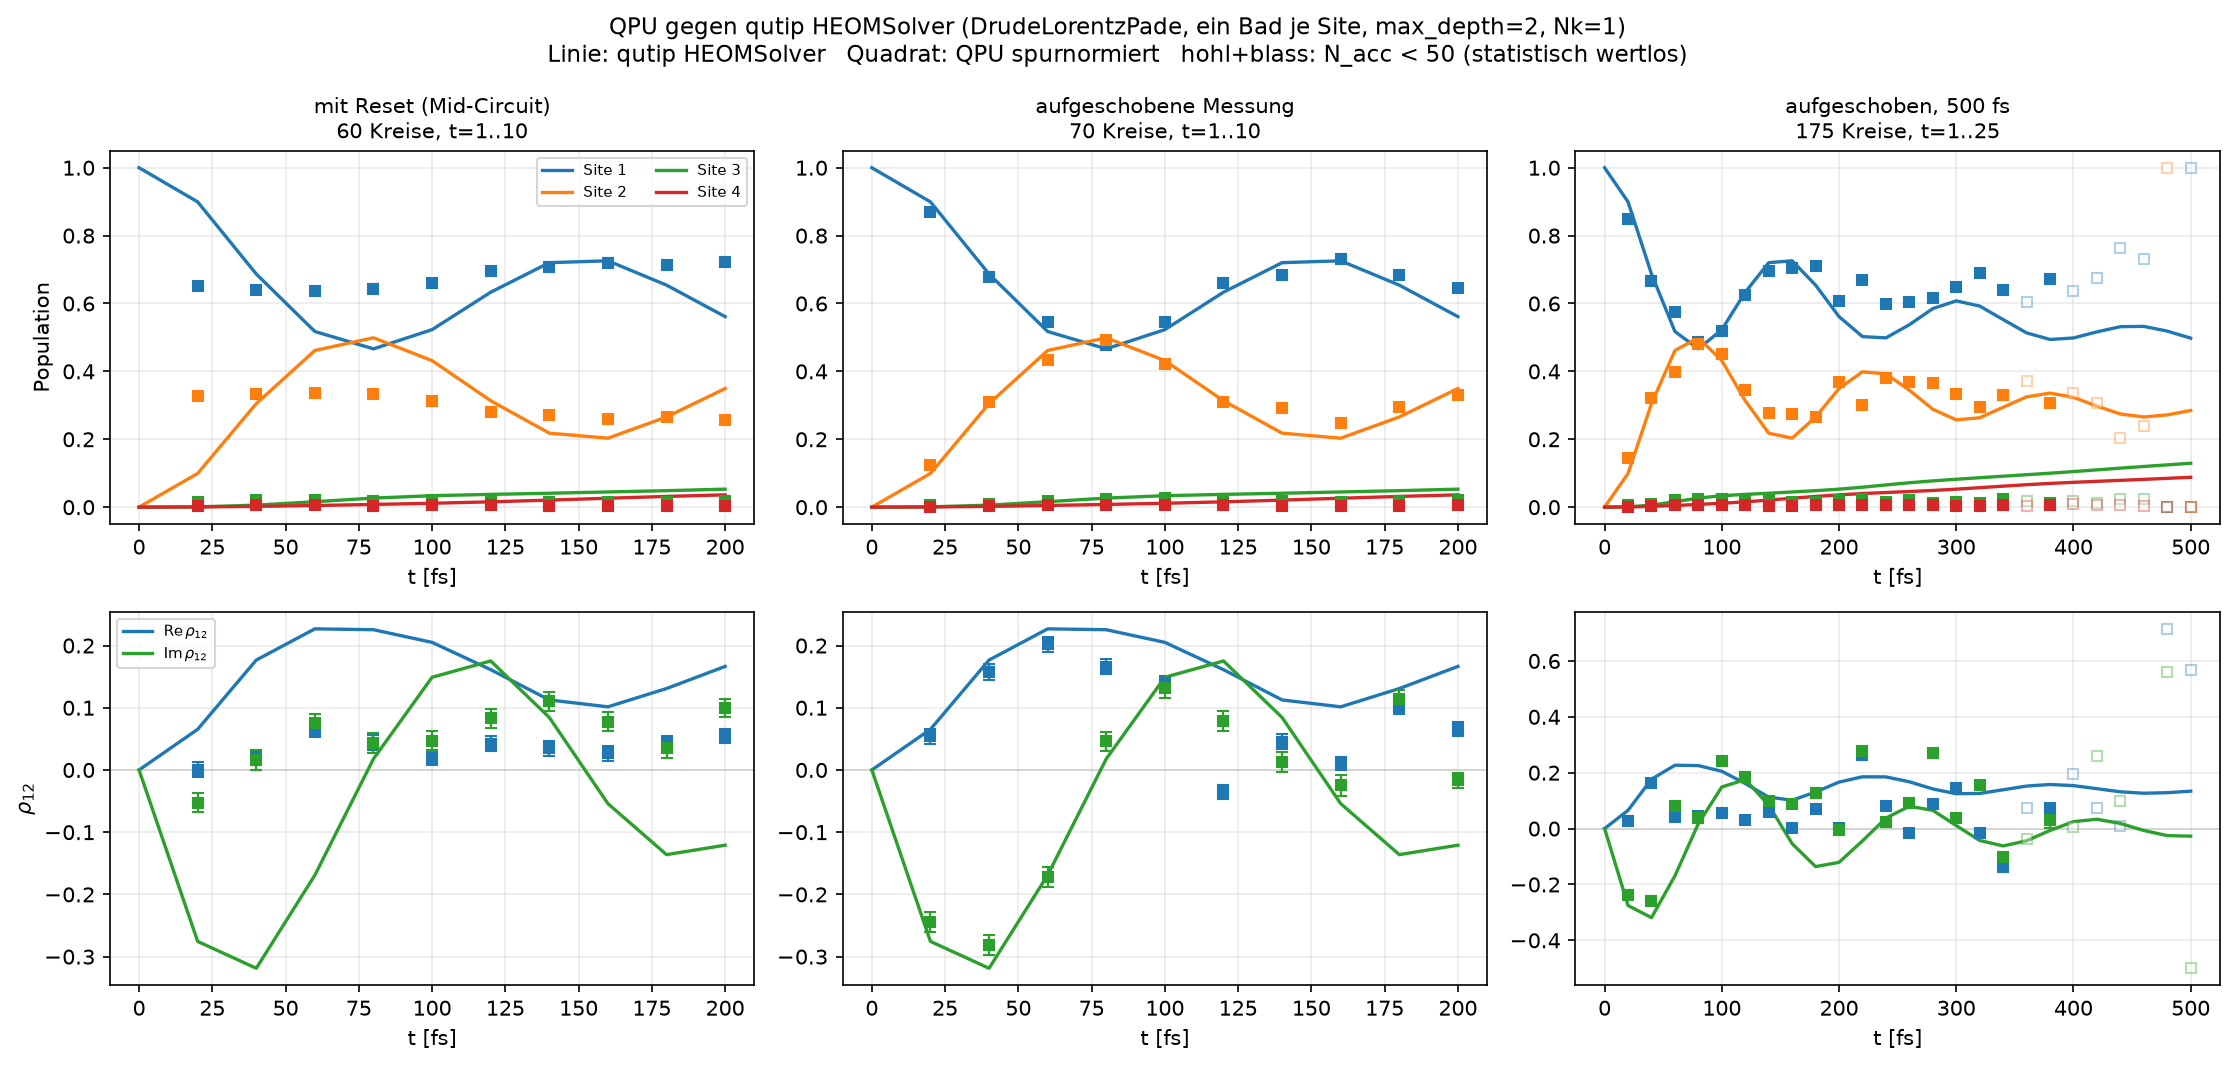

In [38]:
%run plot_npy.py
from IPython.display import Image, display
display(Image('pictures/npy_runs.png'))

---

# 7  Staffel-Schema: $\Delta t = T/3$, immer drei Schritte

Die Krylov-Kompression ist **exakt** für $t \le m-1$, denn
$\mathcal K_m = \operatorname{span}\{y_0, Py_0, \dots, P^{m-1}y_0\}$ enthält
$P^t y_0$ dann per Konstruktion. Bei $m=4$ sind das drei Schritte.

Statt **einen** Schaltkreis über zehn Schritte laufen zu lassen und dabei den
Kompressionsfehler einzusammeln, baut dieses Schema **je Zielzeit ein eigenes
Gitter** mit $\Delta t = T/3$ und geht immer nur drei Schritte. Damit liegt jeder
Lauf vollständig im exakten Bereich:

| | Zeitpunkte | tiefster Kreis | Gattertreue | Kompressionsfehler |
|---|---|---|---|---|
| Abschnitt 1–5: $m{=}4$, 10 Schritte, $\Delta t = 20$ fs | 10 | 138 CZ | 0,656 | 0,0498 |
| $m{=}8$, 5 Schritte, $\Delta t = 20j$ fs | 28 | 388 CZ | 0,306 | 0,000000 |
| **hier: $m{=}4$, 3 Schritte, $\Delta t = T/3$** | **50** | **35 CZ** | **0,899** | **0,0000002** |

In Aer gemessen, 8192 Shots (Shot-Rauschen $1/(2\sqrt N) = 0{,}0055$):

| T [fs] | dt [fs] | $p_{\rm succ}$ | Fehler spurnormiert |
|---|---|---|---|
| 100 | 33,33 | 0,9072 | 0,0018 |
| 400 | 133,33 | 0,8022 | 0,0012 |
| 700 | 233,33 | 0,5593 | 0,0020 |
| 1000 | 333,33 | 0,5055 | 0,0037 |

Der Fehler ist reines Shot-Rauschen und wächst **nicht** mit der Zeit.

### Warum $\Delta t$ nicht auf dem 20-fs-Raster liegt

Läge $\Delta t$ selbst auf einem 20-fs-Raster, wäre $T = 20\,j\,k$, und Zeiten,
die weder durch 2 noch durch 3 teilbar sind (20, 100, 140, 220, 260 fs …),
wären nur mit $k=1$ erreichbar — 17 der 50 Punkte. Bei $k=1$ wendet der
Schaltkreis den Propagator **einmal** an, und die klassische Vorbereitung
berechnet $\exp(A\,T)$, also bereits die Antwort. Mit $\Delta t = T/3$ hat
dagegen **jeder** Punkt den Hebel 3, und Doppelzählungen gibt es gar nicht
erst, weil jede Zielzeit genau eine Darstellung hat.

### Ehrlich zum Anspruch

Der Hebel $T/\Delta t$ beträgt hier nur 3: der Schaltkreis verdreifacht die
klassisch vorbereitete Zeit, während ein 10-Schritt-Lauf sie verzehnfacht. Die
Kurve wird sauberer, die Aussage über den Quantenvorteil schwächer. Das ist der
bewusste Tausch dieses Abschnitts.

In [7]:
# --- Parameter des Staffel-Laufs ----------------------------------------
K_STAFFEL = 3                              # Schritte je Kreis; <= M_KRYLOV-1
T_ZIEL    = np.arange(20.0, 1001.0, 20.0)  # 50 Zeitpunkte, alle 20 fs
CACHE     = 'data/staffel_grids.npz'       # Gitterbau ist teuer -> cachen

grids = hw.staffel_grids(T_ZIEL, n_sites=N_SITES, m=M_KRYLOV, k=K_STAFFEL,
                         delta=DELTA, model=MODEL, rho0=RHO0, cache=CACHE)
print(f"  {len(grids)} Gitter, dt von {grids[0][1]['dt_fs']:.2f} bis "
      f"{grids[-1][1]['dt_fs']:.2f} fs")

  50 Gitter aus data/staffel_grids.npz geladen
  50 Gitter, dt von 6.67 bis 333.33 fs


In [8]:
jobs_s = hw.staffel_circuits(grids, PAIRS, k=K_STAFFEL, method=METHOD,
                             defer=DEFER, floor=FLOOR)
print(f"  {len(jobs_s)} Schaltkreise = {len(jobs_s)//len(grids)} je Zielzeit")
kosten_s = hw.report_cost(grids[0][1], jobs_s, shots=SHOTS)

  300 Schaltkreise = 6 je Zielzeit
  300 Schaltkreise, 3 System- + bis 2 Ancilla-Qubits = 5, 2048 Shots je Schaltkreis, Dilatation 'svd'
  Messung: aufgeschoben -- 0 Resets, alles am Ende
  Zweiqubit-Gatter: 35 bis 39 (Median 38), Tiefe bis 151

    t  2Q-Gatter  Tiefe  Treue (Gatter)
    3         38    141           0.904

  geschaetzte QPU-Zeit : 194.0 s  (3.23 min)
    davon rep_delay    : 191.1 s (98%)
  Annahmen: 2.66e-03 Fehler je 2Q-Gatter, 68 ns je 2Q, 311 us rep_delay, Topologie: lineare Kette
  (rep_delay/t_meas/t_reset kalibriert an Job da833pe0ukec7383ughg: 42 s tatsaechlich)


### 7a  Kostenlos gegenprüfen

Ohne Gatterrauschen bleibt nur die Shot-Statistik übrig — der
Kompressionsfehler ist per Konstruktion null.

In [9]:
rho_as, err_as, info_as = hw.verify_staffel_in_aer(grids, jobs_s, shots=SHOTS,
                                                  pairs=PAIRS)

    25/300 simuliert
    50/300 simuliert
    75/300 simuliert
    100/300 simuliert
    125/300 simuliert
    150/300 simuliert
    175/300 simuliert
    200/300 simuliert
    225/300 simuliert
    250/300 simuliert
    275/300 simuliert
    300/300 simuliert
10.0%. Run time:   0.01s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.02s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00
50.0%. Run time:   0.03s. Est. time left: 00:00:00:00
60.0%. Run time:   0.03s. Est. time left: 00:00:00:00
70.0%. Run time:   0.04s. Est. time left: 00:00:00:00
80.0%. Run time:   0.05s. Est. time left: 00:00:00:00
90.0%. Run time:   0.06s. Est. time left: 00:00:00:00
100.0%. Run time:   0.06s. Est. time left: 00:00:00:00
Total run time:   0.06s

  Aer gegen qutip HEOMSolver (Staffel, k=3):
    T =     20 fs (dt =   6.67) | p_succ 0.9800 | Spur 1.0046 | max|dPop| ueber p_t 0.0055 | spurnormiert 0.0013
    T =     40 

### 7b  Auf die echte Maschine

`LOSSCHICKEN_S = True` setzen, wenn Abschnitt 7 und 7a passen. Der alte Lauf
wird vorher automatisch mit Zeitstempel gesichert.

In [ ]:
COUNTS_FILE_S = 'ibm_kingston_kry_1000fs_staffel.npy'
LOSSCHICKEN_S = False          # auf True setzen, wenn du bereit bist

if LOSSCHICKEN_S:
    if os.path.exists(COUNTS_FILE_S):
        sich = COUNTS_FILE_S.replace('.npy',
                                     f"_{time.strftime('%Y%m%d_%H%M%S')}.npy")
        os.rename(COUNTS_FILE_S, sich)
        print(f"  vorheriger Lauf gesichert als {sich}")
    counts_s = hw.run_on_backend(jobs_s, backend_name=BACKEND, shots=SHOTS)
    np.save(COUNTS_FILE_S, np.array(counts_s, dtype=object), allow_pickle=True)
    print(f"  Zaehlraten gesichert in {COUNTS_FILE_S}")
elif os.path.exists(COUNTS_FILE_S):
    counts_s = list(np.load(COUNTS_FILE_S, allow_pickle=True))
    if len(counts_s) != len(jobs_s):
        print(f"  ACHTUNG: {len(counts_s)} Zaehlraten, aber {len(jobs_s)} "
              f"Schaltkreise -- alter Lauf passt NICHT.  Wird ignoriert.")
        counts_s = None
    else:
        print(f"  {len(counts_s)} gespeicherte Zaehlraten geladen")
else:
    counts_s = None
    print("  Noch nichts abgeschickt.  LOSSCHICKEN_S = True setzen, wenn bereit.")

qiskit_runtime_service.__init__:WARNING:2026-09-10 10:30:28,060: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-10 10:30:28,061: Using instance: open-instance, plan: open


  Backend ibm_kingston: 156 Qubits, Basisgatter ['rz', 'reset', 'x', 'measure_reset', 'sx', 'measure_2', 'measure_reset_2', 'cz', 'if_else', 'reset_2', 'delay', 'id', 'measure']
  ISA-Schaltkreise (das, was wirklich laeuft):
      t          Kanal    2Q  Tiefe  Qubits
      3  ('pop', 0, 0)    35    144     156
      3  ('pop', 1, 1)    36    148     156
      3  ('pop', 2, 2)    36    148     156
      3  ('pop', 3, 3)    36    148     156
      3   ('pp', 0, 1)    35    142     156
      3   ('RR', 0, 1)    38    142     156
      3  ('pop', 0, 0)    38    140     156
      3  ('pop', 1, 1)    39    145     156
      3  ('pop', 2, 2)    36    147     156
      3  ('pop', 3, 3)    36    147     156
      3   ('pp', 0, 1)    35    142     156
      3   ('RR', 0, 1)    34    138     156
      3  ('pop', 0, 0)    35    144     156
      3  ('pop', 1, 1)    36    149     156
      3  ('pop', 2, 2)    36    149     156
      3  ('pop', 3, 3)    36    149     156
      3   ('pp', 0, 1)    3

### 7c  Auswerten und gegen qutip stellen

10.0%. Run time:   0.01s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.02s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00
50.0%. Run time:   0.03s. Est. time left: 00:00:00:00


60.0%. Run time:   0.03s. Est. time left: 00:00:00:00
70.0%. Run time:   0.04s. Est. time left: 00:00:00:00
80.0%. Run time:   0.04s. Est. time left: 00:00:00:00
90.0%. Run time:   0.05s. Est. time left: 00:00:00:00
100.0%. Run time:   0.05s. Est. time left: 00:00:00:00
Total run time:   0.05s

  QPU gegen qutip HEOMSolver (Staffel, k=3):
    T =     20 fs (dt =   6.67) | p_succ 0.8354 | Spur 0.9755 | max|dPop| ueber p_t 0.0990 | spurnormiert 0.0790
    T =     40 fs (dt =  13.33) | p_succ 0.3584 | Spur 0.5945 | max|dPop| ueber p_t 0.3004 | spurnormiert 0.0367
    T =     60 fs (dt =  20.00) | p_succ 0.7832 | Spur 0.9170 | max|dPop| ueber p_t 0.0420 | spurnormiert 0.0040
    T =     80 fs (dt =  26.67) | p_succ 0.7671 | Spur 0.9125 | max|dPop| ueber p_t 0.0522 | spurnormiert 0.0094
    T =    100 fs (dt =  33.33) | p_succ 0.7798 | Spur 0.9306 | max|dPop| ueber p_t 0.0333 | spurnormiert 0.0040
    T =    120 fs (dt =  40.00) | p_succ 0.7339 | Spur 0.9081 | max|dPop| ueber p_t 0.0772 | s

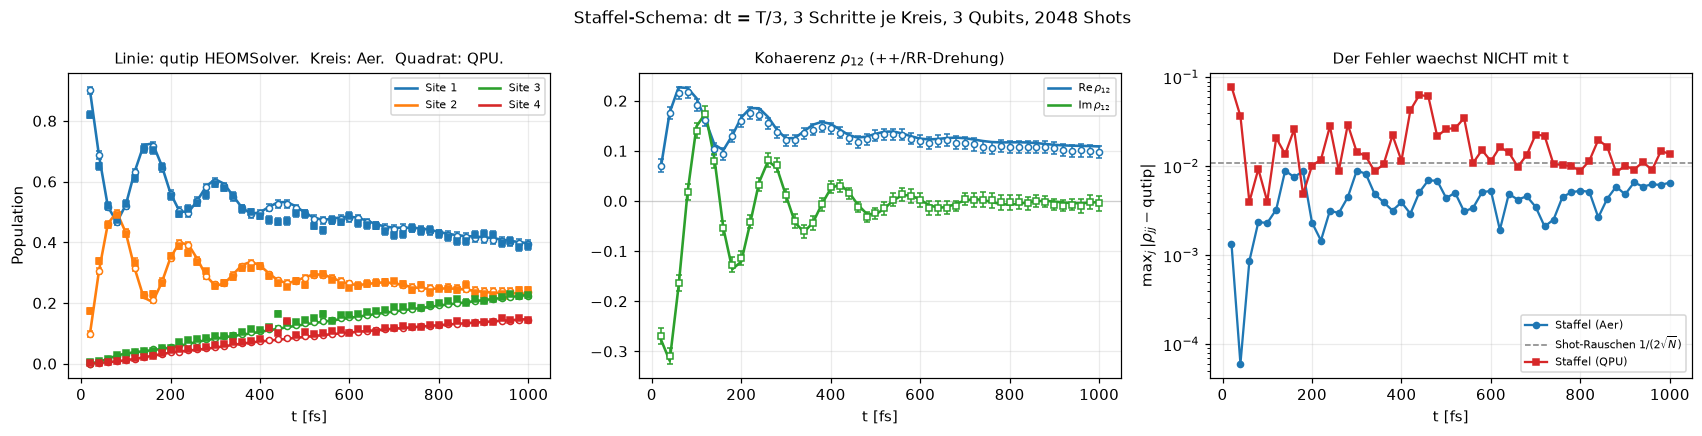

In [13]:
if counts_s is not None:
    rho_hs, err_hs, info_hs = hw.analyze_staffel(grids, jobs_s, counts_s,
                                                 pairs=PAIRS)
    hs_tr = info_hs['rho_tr']
else:
    rho_hs = err_hs = info_hs = hs_tr = None
    print("  !! KEINE Hardwaredaten -- es wird NUR Aer geplottet.")

Ts   = info_as['T_fs']
refs = info_as['reference']
as_tr = info_as['rho_tr']
ok_as = np.isfinite(np.real(rho_as[:, 0, 0]))
ok_h  = (np.isfinite(np.real(rho_hs[:, 0, 0])) if rho_hs is not None else None)

fig, ax = plt.subplots(1, 3, figsize=(15.6, 4))

for j in range(N):                       # (a) Populationen
    ax[0].plot(Ts, np.real(refs[:, j, j]), color=cols[j], lw=1.7,
               label=f'Site {j+1}')
    ax[0].errorbar(Ts[ok_as], np.real(as_tr[ok_as, j, j]),
                   yerr=err_as[ok_as, j, j], fmt='o', ms=4, capsize=2,
                   color=cols[j], mfc='white', lw=1.0)
    if rho_hs is not None:
        ax[0].errorbar(Ts[ok_h], np.real(hs_tr[ok_h, j, j]),
                       yerr=err_hs[ok_h, j, j], fmt='s', ms=4, capsize=2,
                       color=cols[j], lw=1.0)
ax[0].set_ylabel('Population')
ax[0].set_title('Linie: qutip HEOMSolver.  Kreis: Aer.'
                + ('  Quadrat: QPU.' if rho_hs is not None else ''))
ax[0].legend(ncol=2, fontsize=7)

a, b = PAIRS[0]                          # (b) Kohaerenz
for teil, lab, mk, cc, ee in ((np.real, r'\mathrm{Re}', 'o', 'C0', err_as),
                              (np.imag, r'\mathrm{Im}', 's', 'C2',
                               info_as['rho_err_im'])):
    ax[1].plot(Ts, teil(refs[:, a, b]), lw=1.7, color=cc,
               label=rf'${lab}\,\rho_{{{a+1}{b+1}}}$')
    ax[1].errorbar(Ts[ok_as], teil(as_tr[ok_as, a, b]), yerr=ee[ok_as, a, b],
                   fmt=mk, ms=4, capsize=2, mfc='white', lw=1.0, color=cc)
    if rho_hs is not None:          # Hardware-Kohaerenzen -- werden von
        eh = (err_hs if teil is np.real      # analyze_staffel mitberechnet
              else info_hs['rho_err_im'])
        ax[1].errorbar(Ts[ok_h], teil(hs_tr[ok_h, a, b]), yerr=eh[ok_h, a, b],
                       fmt='D', ms=4, capsize=2, lw=1.0, color=cc)
ax[1].axhline(0, color='0.85', lw=.8, zorder=0)
ax[1].set_title(rf'Kohaerenz $\rho_{{{a+1}{b+1}}}$ (++/RR-Drehung)'
                + ('  Raute: QPU.' if rho_hs is not None else ''))
ax[1].legend(fontsize=7)

dmax = lambda R, k: np.abs(np.real(np.diag(R[k]))
                           - np.real(np.diag(refs[k]))).max()
ax[2].semilogy(Ts[ok_as], [dmax(as_tr, k) for k in np.where(ok_as)[0]],
               'o-', ms=4, color='C0', label='Staffel (Aer)')
ax[2].axhline(1 / (2 * np.sqrt(SHOTS)), color='0.5', ls='--', lw=1,
              label=r'Shot-Rauschen $1/(2\sqrt{N})$')
if rho_hs is not None:
    ax[2].semilogy(Ts[ok_h], [dmax(hs_tr, k) for k in np.where(ok_h)[0]],
                   's-', ms=4, color='C3', label='Staffel (QPU)')
ax[2].set_ylabel(r'max$_j\,|\rho_{jj} - $qutip$|$')
ax[2].set_title('Der Fehler waechst NICHT mit t')
ax[2].legend(fontsize=7)

for A in ax:
    A.set_xlabel('t [fs]'); A.grid(alpha=.25)
fig.suptitle(f'Staffel-Schema: dt = T/{K_STAFFEL}, {K_STAFFEL} Schritte je Kreis, '
             f'{grid["n_qubits"]} Qubits, {SHOTS} Shots', fontsize=11)
fig.tight_layout()
fig.savefig(f'{PIC}/staffel.png', dpi=150, bbox_inches='tight')
plt.show()